### 🧠 What is Query Planning and Decomposition?
Query Planning and Decomposition is a technique where a complex user query is broken down into simpler sub-question or tasks, allowing a system (like a RAG agent) to:

- Understand the question more deeply
- Retrieve more precise and complete information
- Execute step-by-step reasoning

It's like reverse-engineering a question into manageable steps before answering.

🧠 What's New in This Version?
- ✅ Add a Query Planner Node
- ✅ Break complex user queries into sub-questions
- ✅ Retrieve docs per sub-question
- ✅ Combine all retrieved contexts
- ✅ Generate a final consolidated answer

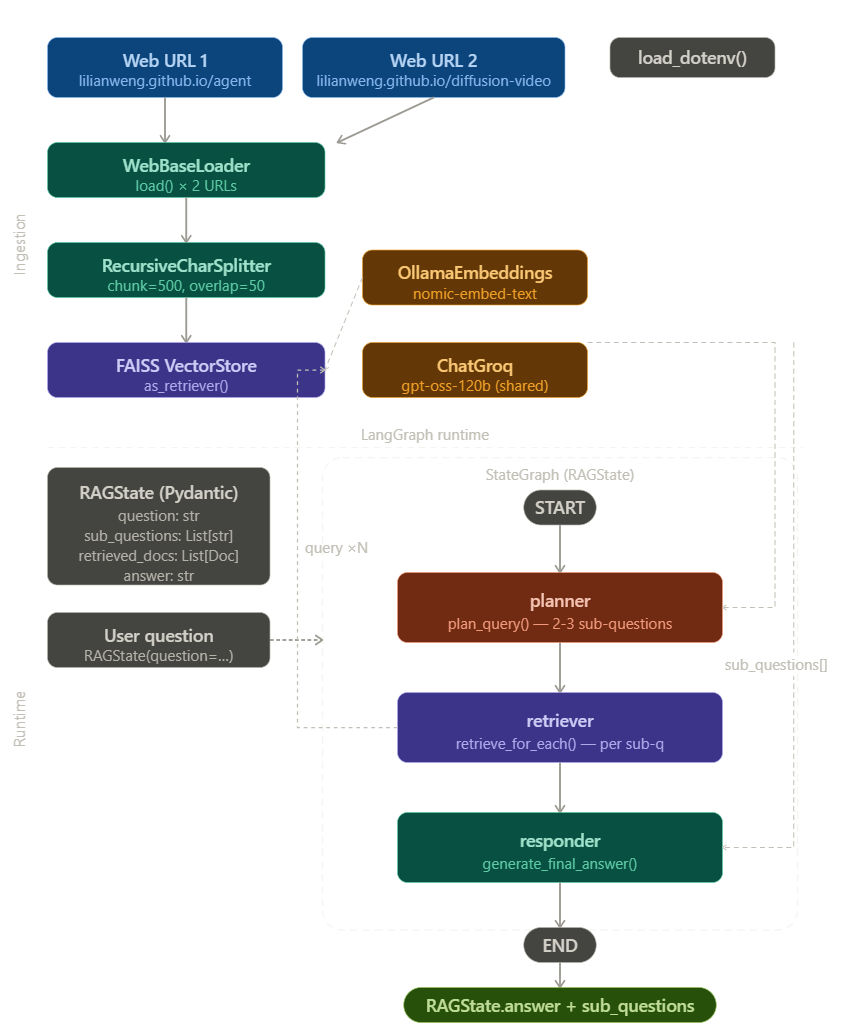

In [7]:
# ------------------------------------------------------------
# 1. Load Text File, Embeddings, Vector Store and LLM 
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/'
]

docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')

vector_db = FAISS.from_documents(chunks, embedding)
retriever = vector_db.as_retriever()

llm = ChatGroq(model='openai/gpt-oss-120b')

In [8]:
# ------------------------------------------------------------
# 2. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document

class RAGState(BaseModel):
    question: str
    sub_questions: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ''

In [12]:
# ------------------------------------------------------------
# 3. Nodes 
# ------------------------------------------------------------

# a) Query Planner: Splits input question
def plan_query(state: RAGState) -> RAGState:
    prompt = f"""
        Break the following question into 2-3 sub-questions:
        
        Question: {state.question}
        Sub-Questions:
    """
    result = llm.invoke(prompt)
    sub_questions = [question.strip('- ').strip() for question in result.content.strip().split('\n') if question.strip()]
    return RAGState(question=state.question, sub_questions=sub_questions)

# b) Retrieve documents for each sub-questions
def retrieve_for_each(state: RAGState) -> RAGState:
    all_docs = []
    for sub in state.sub_questions:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return RAGState(question=state.question, sub_questions=state.sub_questions, retrieved_docs=all_docs)

# c) Generate final answer
def generate_final_answer(state: RAGState) -> RAGState:
    context = '\n\n'.join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
        Use the context below to answer the question.
        
        Context: {context}
        Question: {state.question}
    """
    answer = llm.invoke(prompt).content
    return RAGState(question=state.question, sub_questions=state.sub_questions, retrieved_docs=state.retrieved_docs, answer=answer)

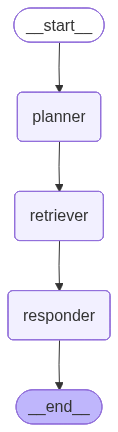

In [13]:
# ------------------------------------------------------------
# 4. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(RAGState)

builder.add_node('planner', plan_query)
builder.add_node('retriever', retrieve_for_each)
builder.add_node('responder', generate_final_answer)

builder.set_entry_point('planner')
builder.add_edge('planner', 'retriever')
builder.add_edge('retriever', 'responder')
builder.add_edge('responder', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# ------------------------------------------------------------
# 5. Run the Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'Explain how agent loops work and what are the challenges in diffusion video generation?'
    state = RAGState(question=query)
    result = graph.invoke(state)
    
    print('\n 🔎 Sub-Questions:')
    for q in result['sub_questions']:
        print('-', q)
    
    print('\n ✅ Final Answer: \n', result['answer'])


 🔎 Sub-Questions:
- **Sub‑Questions**
- 1. **What are agent loops and how do they operate?**
- What are the main components of an agent loop (perception, reasoning, action, feedback)?
- How does the loop iterate to achieve goal‑directed behavior?
- 2. **How are agent loops applied in practice, and what design considerations affect their performance?**
- In what types of AI systems (e.g., autonomous agents, LLM‑driven agents) are agent loops commonly used?
- What are the typical challenges related to loop stability, error propagation, and resource constraints?
- 3. **What are the primary challenges in diffusion‑based video generation?**
- How do issues such as temporal consistency, computational cost, and model scalability impact diffusion video generation?
- What current research directions aim to mitigate these challenges?

 ✅ Final Answer: 
 **Agent loops**

In LLM‑powered autonomous agents the whole system is organized as a tight **perception‑reason‑act** loop that repeats until a 